### Import Dependencies

In [76]:
import openai
import pandas as pd
from qdrant_client import QdrantClient, models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier,PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from typing import Literal, Annotated, List, Any
from operator import add
import random
from jinja2 import Template
from langchain_core.messages import SystemMessage, HumanMessage
import instructor
from langsmith import traceable, get_current_run_tree

In [2]:
def get_embedding(text, model='text-embedding-3-small'):
    response = openai.embeddings.create(
        model=model,
        input=text,
    )
    return response.data[0].embedding

In [3]:
def retrieve_data(query, qdrant_client, collection_name='amazon-items-collection-01-hybrid-search', k=5):
    query_embedding = get_embedding(query)

    results = qdrant_client.query_points(
        collection_name=collection_name,
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25",
                ),
                using="bm25",
                limit=20
            )
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
        limit=k
    )

    retrieved_context_ids = []
    retrieved_context_scores = []
    retrieved_context_texts = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload['parent_asin'])
        retrieved_context_scores.append(result.score)
        retrieved_context_texts.append(result.payload['processed_description'])
        retrieved_context_ratings.append(result.payload['average_rating'])

    return {
        'retrieved_context_ids': retrieved_context_ids,
        'retrieved_context_scores': retrieved_context_scores,
        'retrieved_context_texts': retrieved_context_texts,
        'retrieved_context_ratings': retrieved_context_ratings
    }

In [4]:
def process_context(retrieve_context):
    formatted_context = ''

    for id, chunk, rating in zip(retrieve_context['retrieved_context_ids'], retrieve_context['retrieved_context_texts'], retrieve_context['retrieved_context_ratings']):
        formatted_context += f"- Product ID: {id}, Product Rating: {rating}, Product Description: {chunk}\n"

    return formatted_context


In [5]:
qdrant_client = QdrantClient(url='http://localhost:6333')

In [6]:
query = "can I get a table?"

In [7]:
answer = retrieve_data(query, qdrant_client)

In [8]:
answer

{'retrieved_context_ids': ['B09VDK8198',
  'B0BB55QVMT',
  'B09YXPJ16J',
  'B0BN58Z4YX',
  'B0BXC72RLD'],
 'retrieved_context_scores': [0.9333333, 0.8928572, 0.71428573, 0.5, 0.45],
 'retrieved_context_texts': ["Under Desk Cable Management Tray 2 Pieces Steel Under Desk Wires Organizer Power Strip Management No Drill Under Table Organizer for Cable Storage Holder for Office Home Desk/Table（Premium Metal） Tidy & Safe With Cable：Under Table Organizer For Cable Storage Tray Can Make The Messy Cables Under The Table Neat And Regular, Free Up The Space Under Your Table, Easy To Clean The Garbage Under The Table, Make The Cables Under Your Table Safer, And Avoid The Short Circuit Caused By Cable Entanglement Larger Capacity Cable Tray: Our Under Table Cable Storage Organizer Holder Has Been Widened, Which Can Accommodate More Cables And Wires, And Can Put Down Two 9.45*4.33In Power Strips At The Same Time, Which Can Make a Lot Of Messy Cables Under Your Desk Neat And Tidy, You Can Also Put A

### Multi-intent questions

In [9]:
query = "Can I get a table for my kid, a watch for me and a laptop for my wife?"

In [10]:
answer = retrieve_data(query, qdrant_client, k=10)

In [11]:
answer

{'retrieved_context_ids': ['B0BZM8YN4K',
  'B0BGHBL86V',
  'B0BN58Z4YX',
  'B0B157WDDJ',
  'B09X1BSKJD',
  'B0B159KDFP',
  'B0BC78N85F',
  'B09W2BMG5N',
  'B0B3R74TZC',
  'B0BT83RRJ2'],
 'retrieved_context_scores': [0.8000001,
  0.75000006,
  0.75,
  0.65,
  0.4761905,
  0.47619045,
  0.37500003,
  0.33333334,
  0.27272725,
  0.25],
 'retrieved_context_texts': ['4G GPS smart watch for boy girl 3-15 years old Kids Global Real-Time tracking watches Waterproof Cell Phone watch Child Video Chat Device SOS Alarm Camera Geo-Fence Pedometer Anti-Lost Tracker Locator 💎 [Multi functions kids smart watch with gps tracker and calling]: The main functions of the kids phone watch include Real Time GPS Position, phone call, video call, SOS Call, Voice Chat, Camera, Photo album, Phone Book, Alarm Clock, Class Mode, Safety Fence, Pedometer, Historical Route etc. This kids gps watches is a perfect Christmas Birthday gift for your girls and boys. 💎 [Waterproof smart watch for kids 8-12]: The waterproof 

In [12]:
class QueryExpandResponse(BaseModel):
    statements: List[str] = Field(description="A list of statements that are related to the original query")

In [13]:
def query_espansion_node(query: str) -> dict:
    prompt_template = """
    You are a query expansion module in a shopping assistant. Your job is to rewrite the customer's query into distinct statements for semantic search.
    ## Instructions:
    - Expand the customer's query into a list of distinct statements (1 to 5 concise statements)
    - Each statement should capture a separate product or attribute from the query
    - Use natural product description language
    - Do not produce multiple statements that express the same intent

    ## Examples:
    Query: "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
    Statements:
    - tablet for kids
    - watch for adults
    - laptop

    Query: "I need a warm winter jacket for hiking"
    Statements:
    - warm winter jacket
    - hiking outfit for cold weather

    <query>:
    {{query}}
    </query>
    """
    template = Template(prompt_template)
    prompt = template.render(query=query)
    
    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
        ],
        response_model=QueryExpandResponse,
        reasoning={"effort":"none"}
    )
    return {
        'queries': response.statements
    }

In [14]:
answer = query_espansion_node("Can I get a lantern for hiking and a table for my wife?")

In [15]:
answer

{'queries': ['lantern for hiking', 'table for wife']}

### LangGraph

### 1. Query Expansion (Sequential Execution)

In [59]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
        

In [60]:
class QueryExpandResponse(BaseModel):
    statements: List[str] = Field(description="A list of statements that are related to the original query")

In [61]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model": "gpt-5.4-mini"
    }
)

def query_expansion_node(state: State) -> dict:
    prompt_template = """
    You are a query expansion module in a shopping assistant. Your job is to rewrite the customer's query into distinct statements for semantic search.
    ## Instructions:
    - Expand the customer's query into a list of distinct statements (1 to 5 concise statements)
    - Each statement should capture a separate product or attribute from the query
    - Use natural product description language
    - Do not produce multiple statements that express the same intent

    ## Examples:
    Query: "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
    Statements:
    - tablet for kids
    - watch for adults
    - laptop

    Query: "I need a warm winter jacket for hiking"
    Statements:
    - warm winter jacket
    - hiking outfit for cold weather

    <query>:
    {{query}}
    </query>
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    
    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
        ],
        response_model=QueryExpandResponse,
        reasoning={"effort":"none"}
    )
    return {
        'expanded_query': response.statements
    }

### 2. Retrieval node

In [62]:
@traceable(
    name='embed_query',
    run_type='embedding',
    metadata={
        'ls_provider': 'openai',
        'ls_model_name': 'text-embedding-3-small',
    },
)
def get_embedding(text, model='text-embedding-3-small'):
    response = openai.embeddings.create(
        model=model,
        input=text,
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata['usage_metadata'] = {
            'input_tokens': response.usage.prompt_tokens,
            'total_tokens': response.usage.total_tokens,
        }
    
    return response.data[0].embedding

@traceable(
    name='retrieve_data',
    run_type='retriever',
)
def retrieve_data(query, qdrant_client, collection_name='amazon-items-collection-01-hybrid-search', k=5):
    query_embedding = get_embedding(query)

    results = qdrant_client.query_points(
        collection_name=collection_name,
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25",
                ),
                using="bm25",
                limit=20
            )
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
        limit=k
    )

    retrieved_context_ids = []
    retrieved_context_scores = []
    retrieved_context_texts = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload['parent_asin'])
        retrieved_context_scores.append(result.score)
        retrieved_context_texts.append(result.payload['processed_description'])
        retrieved_context_ratings.append(result.payload['average_rating'])
    
    formatted_context = ''

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context_texts, retrieved_context_ratings):
        formatted_context += f"- Product ID: {id}, Product Rating: {rating}, Product Description: {chunk}\n"
    
    return formatted_context

@traceable(
    name='retriever_node',
    run_type='retriever'
)
def retriever_node(state: State) -> dict:
    qdrant_client = QdrantClient(url='http://localhost:6333')
    retrieved_context = []

    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query, qdrant_client))

    return {
        'retrieved_context': retrieved_context
    }


### 3. Aggregator node

In [63]:
class AggregatorResponse(BaseModel):
    answer: str

In [64]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model": "gpt-5.4-mini"
    }
)

def aggregator_node(state: State) -> dict:
    preprocessed_context = '\n'.join(state.retrieved_context)

    prompt_template = """
    You are a shopping assistant that can answer questions about the products in stock.
      
    You will be given a question and a list of context.

    Instructions:
    - Answer the question based on the context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain  detailed information about the product and returned with detailed specification in bullet points.

    Context:
    {{preprocessed_context}}

    Question:
    {{question}}
    """
    template = Template(prompt_template)
    prompt = template.render(preprocessed_context=preprocessed_context, question=state.initial_query)
    
    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
        ],
        response_model=AggregatorResponse,
        reasoning={"effort":"none"}
    )
    return {
        'answer': response.answer
    }

In [65]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node('retriever_node', retriever_node)
workflow.add_node('aggregator_node', aggregator_node)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

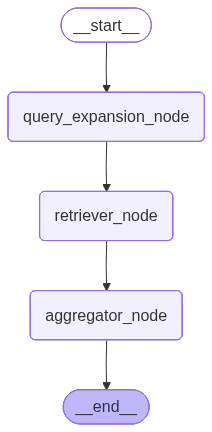

In [66]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [67]:
query = "Can I get a laptop for me and a watch for my wife?"

In [68]:
initial_state = {
    "initial_query": query
}

In [69]:
result = graph.invoke(initial_state)

In [70]:
result

{'expanded_query': ['laptop for adults', 'watch for adults'],
 'retrieved_context': ['- Product ID: B09GLJFNZW, Product Rating: 4.4, Product Description: HOMIEE Travel Laptop Backpack for Men Women, Business Computer Backpack with USB Port, Anti Theft Backpack Casual Daypack Carry on Bag 【Large Capacity & Multifunctional】: Roomy main compartment has two laptop pockets to put laptop computer for screen sizes up to 15.6 inches and tablets, extra large space to hold books, folders, clothes, towels, handkerchiefs etc. Two internal pockets, pen slots and exterior zip pocket are provided for storing small items such as cards, keys, wallets, sunglasses, camera electronics accessories. Dual side pockets can store water bottles or umbrellas, and the back pocket can store mobile phones. 【Safe & Practical Anti-Theft Design】: The anti theft pockets on back and inner front of the laptop backpack can protect your passport, wallet, phone and other valuable items from being stolen. Anti-theft backpack

In [72]:
print(result['answer'])

Based on the available products, there is no actual laptop listed. The closest laptop-related items are laptop accessories such as backpacks, sleeves, and laptop stands.

For a watch, there is a kids 4G GPS smart watch and a very minimal smart watch listing, but no standard adult watch specifically for a wife.

Available product details:
- HOMIEE Travel Laptop Backpack for Men Women
  - Product ID: B09GLJFNZW
  - Rating: 4.4
  - Fits laptops up to 15.6 inches
  - USB charging port
  - Anti-theft pockets
  - Waterproof nylon fabric
  - Luggage strap for travel
  - Adjustable padded shoulder straps

- Ferkurn Laptop Sleeve Case / Shoulder Bag
  - Product ID: B08H7XBRWQ
  - Rating: 4.7
  - Fits most 14-15.6 inch laptops
  - Slim and lightweight
  - Removable shoulder strap
  - Water-repellent polyester

- HUANUO Adjustable Laptop Stand
  - Product ID: B0B1HN1DK2
  - Rating: 4.4
  - Fits most 10-17.3 inch laptops
  - Adjustable height up to 12 inches
  - Supports up to 17.6 lbs
  - Foldabl

### 2. Query Expansion (Parallel execution)

In [121]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

In [122]:
class QueryExpandResponse(BaseModel):
    statements: List[str] = Field(description="A list of statements that are related to the original query")

In [123]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model": "gpt-5.4-mini"
    }
)

def query_expansion_node(state: State) -> dict:
    prompt_template = """
    You are a query expansion module in a shopping assistant. Your job is to rewrite the customer's query into distinct statements for semantic search.
    ## Instructions:
    - Expand the customer's query into a list of distinct statements (1 to 5 concise statements)
    - Each statement should capture a separate product or attribute from the query
    - Use natural product description language
    - Do not produce multiple statements that express the same intent

    ## Examples:
    Query: "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
    Statements:
    - tablet for kids
    - watch for adults
    - laptop

    Query: "I need a warm winter jacket for hiking"
    Statements:
    - warm winter jacket
    - hiking outfit for cold weather

    <query>:
    {{query}}
    </query>
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    
    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
        ],
        response_model=QueryExpandResponse,
        reasoning={"effort":"none"}
    )
    return {
        'expanded_query': response.statements
    }

In [124]:
def query_expand_conditional_edges(state: State) -> dict:
    send_messages = []
    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )
    return send_messages        

### 1. Retrieval node

In [125]:
@traceable(
    name='embed_query',
    run_type='embedding',
    metadata={
        'ls_provider': 'openai',
        'ls_model_name': 'text-embedding-3-small',
    },
)
def get_embedding(text, model='text-embedding-3-small'):
    response = openai.embeddings.create(
        model=model,
        input=text,
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata['usage_metadata'] = {
            'input_tokens': response.usage.prompt_tokens,
            'total_tokens': response.usage.total_tokens,
        }
    
    return response.data[0].embedding

@traceable(
    name='retriever_node',
    run_type='retriever',
)
def retriever_node(state: State) -> dict:
    qdrant_client = QdrantClient(url='http://localhost:6333')
    query_embedding = get_embedding(state['query'])

    results = qdrant_client.query_points(
        collection_name="amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25",
                ),
                using="bm25",
                limit=20
            )
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
        limit=state['k']
    )

    retrieved_context_ids = []
    retrieved_context_scores = []
    retrieved_context_texts = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload['parent_asin'])
        retrieved_context_scores.append(result.score)
        retrieved_context_texts.append(result.payload['processed_description'])
        retrieved_context_ratings.append(result.payload['average_rating'])
    
    formatted_context = ''

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context_texts, retrieved_context_ratings):
        formatted_context += f"- Product ID: {id}, Product Rating: {rating}, Product Description: {chunk}\n"
    
    return {
        "retrieved_context": [formatted_context]
    }

### 2. Aggregator node

In [126]:
class AggregatorResponse(BaseModel):
    answer: str

In [127]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model": "gpt-5.4-mini"
    }
)

def aggregator_node(state: State) -> dict:
    preprocessed_context = '\n'.join(state.retrieved_context)

    prompt_template = """
    You are a shopping assistant that can answer questions about the products in stock.
      
    You will be given a question and a list of context.

    Instructions:
    - Answer the question based on the context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain  detailed information about the product and returned with detailed specification in bullet points.

    Context:
    {{preprocessed_context}}

    Question:
    {{question}}
    """
    template = Template(prompt_template)
    prompt = template.render(preprocessed_context=preprocessed_context, question=state.initial_query)
    
    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    response, raw_response = client.create_with_completion(
        messages = [
            {"role":"system", "content":prompt},
        ],
        response_model=AggregatorResponse,
        reasoning={"effort":"none"}
    )
    return {
        'answer': response.answer
    }

In [128]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node('retriever_node', retriever_node)
workflow.add_node('aggregator_node', aggregator_node)

workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges
)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

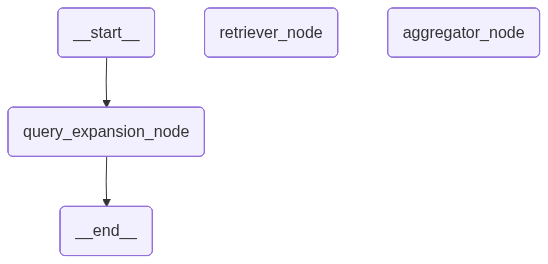

In [129]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [130]:
query = "Can I get a laptop for me and a watch for my wife?"

In [131]:
initial_state = {
    "initial_query": query
}

In [132]:
result = graph.invoke(initial_state)

In [133]:
print(result['answer'])

Yes — based on the available products, I can recommend one laptop and one watch.

- For you: A laptop option is the jumper 2 in 1 Laptop (Product ID: B0B9XSS7DC)
  - Rating: 3.6
  - 11.6-inch HD touch screen (1366 x 768)
  - Intel Celeron N4000
  - Windows 11
  - 4GB DDR4 RAM
  - 128GB eMMC storage
  - Supports expansion up to 1TB SSD
  - 360-degree convertible design
  - About 1kg weight
  - Battery life: about 5 hours
  - Includes microphone and 2.0 MP front camera for meetings/video calls
  - Good for basic home use and school work

- For your wife: A women’s smartwatch option is the Iaret Smart Watch for Women (Product ID: B0BYZW2X6G)
  - Rating: 4.0
  - 1.32-inch full-touch round color screen
  - Bluetooth dialing and answering calls
  - SMS and app notifications
  - 20 sports modes
  - Heart rate, blood pressure, blood oxygen, and sleep monitoring
  - IP67 waterproof
  - Comes with 3 bands: rose gold stainless steel, pink silicone, and burgundy silicone
  - Battery life: up to 3–